### Class 35 and 36 Notes + workout
Date: 15 April 2026 (by Vikram Khaire)

Topic: FFT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# These two libraries are for the animations 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML 


#### FFT Demo

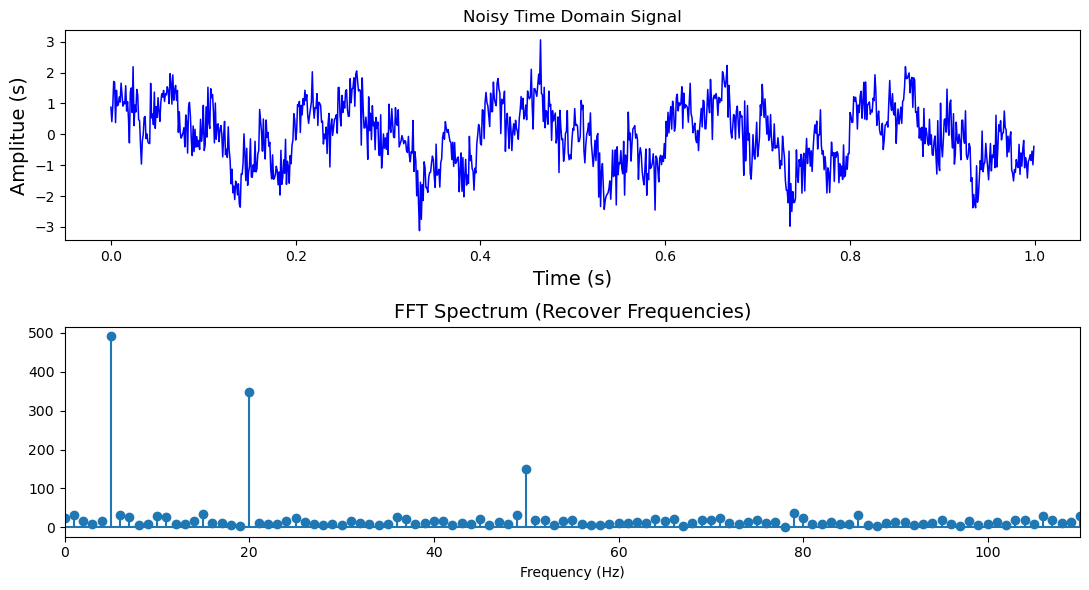

In [2]:
# ------------------------------------------------------------
# PART 1: FFT on a noisy mixed-frequency signal
# ------------------------------------------------------------

def fft_demo():
    np.random.seed(0)

    
    # Sampling parameters
    fs = 1000  # sampling frequency (Hz)
    t = np.linspace(0, 1, fs, endpoint=False)
    
    # Create mixed signal -- that we will reveal later using FFT
    f1, f2, f3 = 5, 20, 50
    signal = (np.sin(2*np.pi*f1*t) +
              0.7*np.sin(2*np.pi*f2*t) +
              0.3*np.sin(2*np.pi*f3*t))

    # Add noise
    Amp = 0.5 # noise amplitude  -- change it to see what happens -- there is a degeneracy between fs and Amp
    noise = Amp * np.random.randn(len(t))
    noisy_signal = signal + noise

    # FFT
    fft_vals = np.fft.fft(noisy_signal)
    freqs = np.fft.fftfreq(len(t), 1/fs)

    # Only positive frequencies
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]
    fft_vals = np.abs(fft_vals[pos_mask])

    # Plot
    fig, axs = plt.subplots(2, 1, figsize=(11, 6))

    axs[0].plot(t, noisy_signal, color = 'b', linewidth = 1.1)
    #axs[0].set_xlim(0, 0.0001)

    axs[0].set_title("Noisy Time Domain Signal")
    axs[0].set_xlabel("Time (s)", fontsize = 14)
    axs[0].set_ylabel("Amplitue (s)", fontsize = 14)


    axs[1].stem(freqs, fft_vals, basefmt="")
    axs[1].set_xlim(0, 110) # I am putting some limit here, but it should be at the max sampling divided by 2 
    axs[1].set_title("FFT Spectrum (Recover Frequencies)", fontsize = 14)
    axs[1].set_xlabel("Frequency (Hz)")

    plt.tight_layout()
    plt.show()

# Run demo
fft_demo()

#


#### Demo to show how the DFT works 

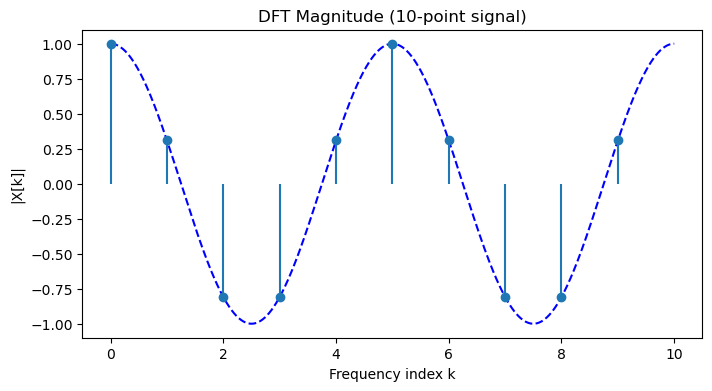

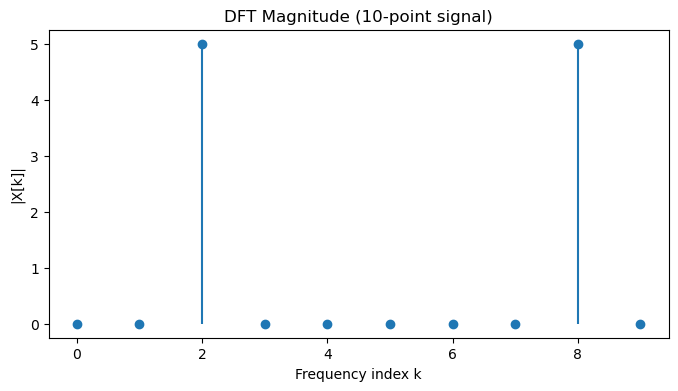

In [3]:
def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Small signal
N = 10
n = np.arange(N)
f_signal = 2  # true frequency index
x = np.cos(2*np.pi*f_signal*n/N)

# Smooth curve (for visualization only)
t = np.linspace(0, N, 1000)
x_smooth = np.cos(2*np.pi*f_signal*t/N)

plt.figure(figsize=(8,4))
plt.plot(t, x_smooth, c= 'b', linestyle = '--')
plt.stem(x, basefmt=" ")
plt.title("DFT Magnitude (10-point signal)")
plt.xlabel("Frequency index k")
plt.ylabel("|X[k]|")
plt.show()

# Compute DFT
X = dft(x)

# Plot full DFT
plt.figure(figsize=(8,4))
plt.stem(np.abs(X), basefmt=" ")
plt.title("DFT Magnitude (10-point signal)")
plt.xlabel("Frequency index k")
plt.ylabel("|X[k]|")
plt.show()

#### Elaborating the basic concept with an animation

In [4]:
# basic concept

# -------------------------------
# Signal
# -------------------------------
N = 10
n = np.arange(N)
f_signal = 2
x = np.cos(2*np.pi*f_signal*n/N)

# -------------------------------
# Prepare figure
# -------------------------------
fig, ax = plt.subplots(figsize=(8,4))

line, = ax.plot(n, np.zeros_like(n), 'o-')
ax.set_xlim(0, N-1)
ax.set_ylim(-2, 2)
ax.axhline(0, linestyle = '--', color ='cyan')

time_text = ax.text(0.02, 0.85, '', transform=ax.transAxes)

ax.set_xlabel("n")
ax.set_ylabel("Amplitude")

# -------------------------------
# Update function (your style)
# -------------------------------
def update(k):
    basis = np.cos(2*np.pi*k*n/N)
    product = x * basis

    line.set_ydata(product)
    time_text.set_text(f"k = {k}")

    ax.set_title("DFT Projection (signal × basis)")
    return line, time_text

# -------------------------------
# Animation
# -------------------------------
anim = FuncAnimation(fig, update, frames=N, interval=1000, blit=True)

plt.close(fig)
HTML(anim.to_jshtml())

#### More detailded animation below

In [5]:
# -------------------------------
# Signal
# -------------------------------
N = 10
n = np.arange(N)
f_signal = 2
x = np.cos(2*np.pi*f_signal*n/N)

fig, ax = plt.subplots(figsize=(8,4))

line1, = ax.plot(n, x, 'o-', label="Signal")
line2, = ax.plot(n, np.zeros_like(n), 'o-', label="Basis")
line3, = ax.plot(n, np.zeros_like(n), 'o-', label="Product")
ax.axhline(0, linestyle = '--', color ='cyan')

ax.set_xlim(0, N-1)
ax.set_ylim(-2, 2)
ax.legend()

time_text = ax.text(0.02, 0.85, '', transform=ax.transAxes)

def update(k):
    basis = np.cos(2*np.pi*k*n/N)
    product = x * basis

    line2.set_ydata(basis)
    line3.set_ydata(product)
    time_text.set_text(f"k = {k}")

    ax.set_title("DFT = Projection onto Basis")
    return line2, line3, time_text

anim = FuncAnimation(fig, update, frames=N, interval=1000, blit=True)

plt.close(fig)
HTML(anim.to_jshtml())

### DFT in the matrix form

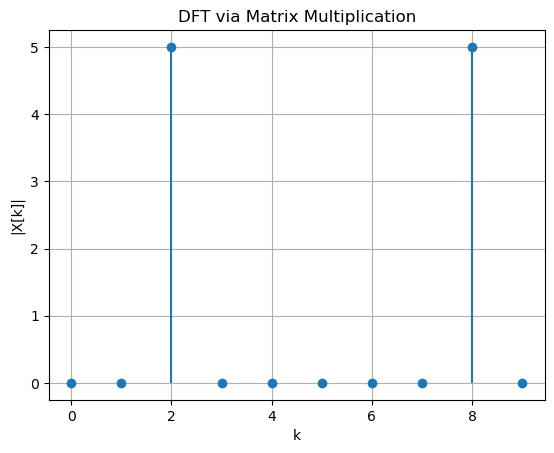

In [6]:
# How to do the calculation in matrix form

# -------------------------------
# Signal
N = 10
n = np.arange(N)
f_signal = 2
x = np.cos(2*np.pi*f_signal*n/N)

# -------------------------------
# DFT matrix
# -------------------------------
k = n.reshape((N,1))
W = np.exp(-2j*np.pi*k*n/N)

# -------------------------------
# Matrix multiplication
# -------------------------------
X = W @ x

# -------------------------------
# Plot
# -------------------------------
plt.stem(np.abs(X), basefmt=" ")
plt.title("DFT via Matrix Multiplication")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()

#### How does the DFT matrix W looks like?

In [7]:
W[:, 0]

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j])

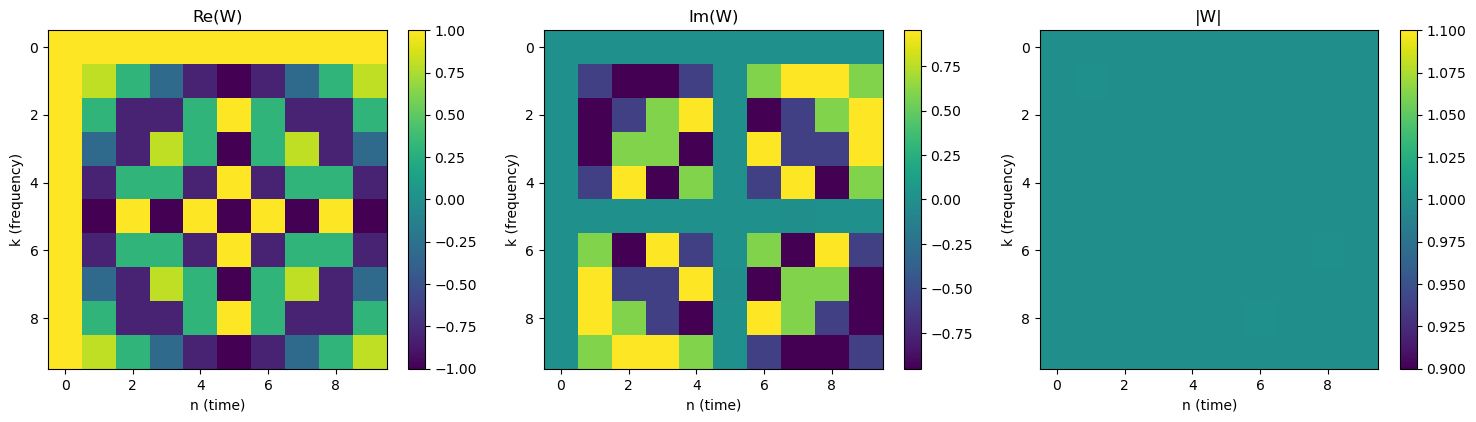

In [8]:
N = 10
n = np.arange(N)
k = n.reshape((N,1))

# DFT matrix
W = np.exp(-2j*np.pi*k*n/N)

# -------------------------------
# Plot real, imaginary, magnitude
# -------------------------------
fig, axs = plt.subplots(1, 3, figsize=(15,4))

im0 = axs[0].imshow(W.real)
axs[0].set_title("Re(W)")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(W.imag)
axs[1].set_title("Im(W)")
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.abs(W))
axs[2].set_title("|W|")
plt.colorbar(im2, ax=axs[2])

for ax in axs:
    ax.set_xlabel("n (time)")
    ax.set_ylabel("k (frequency)")

plt.tight_layout()
plt.show()

## Exra demo of for using the FFT to compress the image 

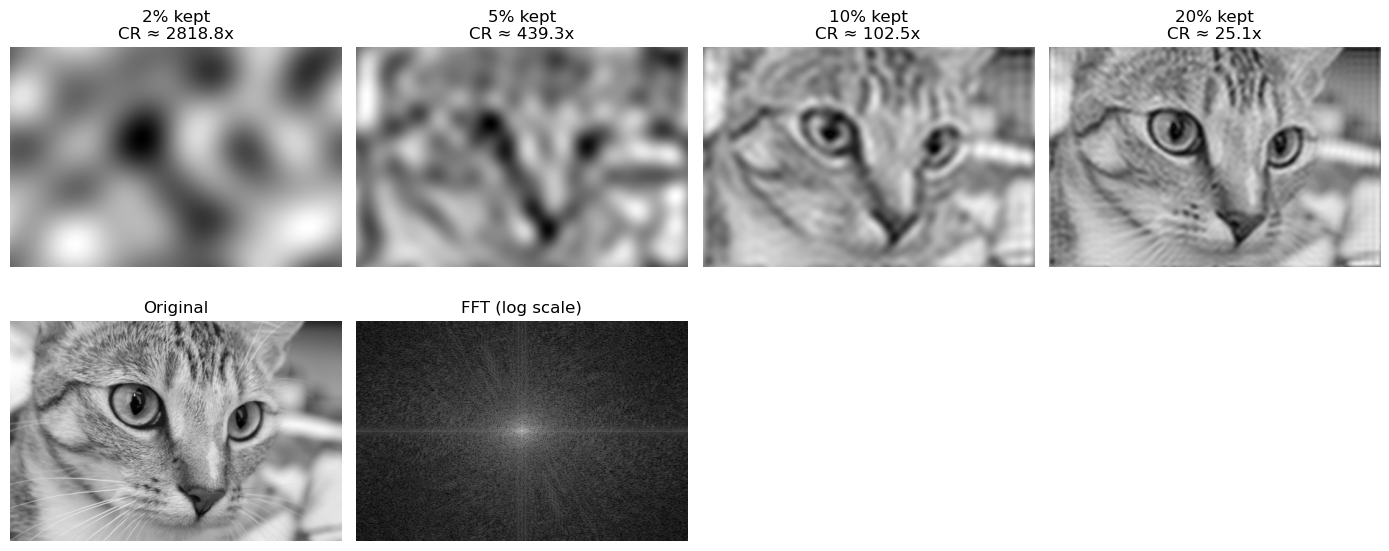

In [9]:
# ---- demo using the square filter

# import for the Cat images
from skimage import data
from skimage.color import rgb2gray

# -------------------------------
# Load image
# -------------------------------
img = data.chelsea()
img_gray = rgb2gray(img)

# -------------------------------
# FFT
# -------------------------------
F = np.fft.fft2(img_gray)
F_shift = np.fft.fftshift(F)

# -------------------------------
# Compression function (central mask)
# -------------------------------
def compress_fft(F_shift, keep_fraction):
    M, N = F_shift.shape
    mask = np.zeros_like(F_shift, dtype=bool)

    m_keep = int(M * keep_fraction)
    n_keep = int(N * keep_fraction)

    m_center = M // 2
    n_center = N // 2

    mask[m_center - m_keep//2 : m_center + m_keep//2,
         n_center - n_keep//2 : n_center + n_keep//2] = True

    return F_shift * mask, mask

# -------------------------------
# Try different compression levels
# -------------------------------
fractions = [0.02, 0.05, 0.1, 0.2]

plt.figure(figsize=(14,6))

for i, frac in enumerate(fractions):
    F_comp, mask = compress_fft(F_shift, frac)

    # Reconstruction
    img_rec = np.fft.ifft2(np.fft.ifftshift(F_comp))
    img_rec = np.abs(img_rec)

    # Compression ratio
    total = F_shift.size
    kept = np.sum(mask)
    ratio = total / kept

    # Plot
    plt.subplot(2, len(fractions), i+1)
    plt.imshow(img_rec, cmap='gray')
    plt.title(f"{int(frac*100)}% kept\nCR ≈ {ratio:.1f}x")
    plt.axis('off')

# -------------------------------
# Original
# -------------------------------
plt.subplot(2, len(fractions), len(fractions)+1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

# -------------------------------
# Frequency spectrum
# -------------------------------
plt.subplot(2, len(fractions), len(fractions)+2)
plt.imshow(np.log(1 + np.abs(F_shift)), cmap='gray')
plt.title("FFT (log scale)")
plt.axis('off')

plt.tight_layout()
plt.show()

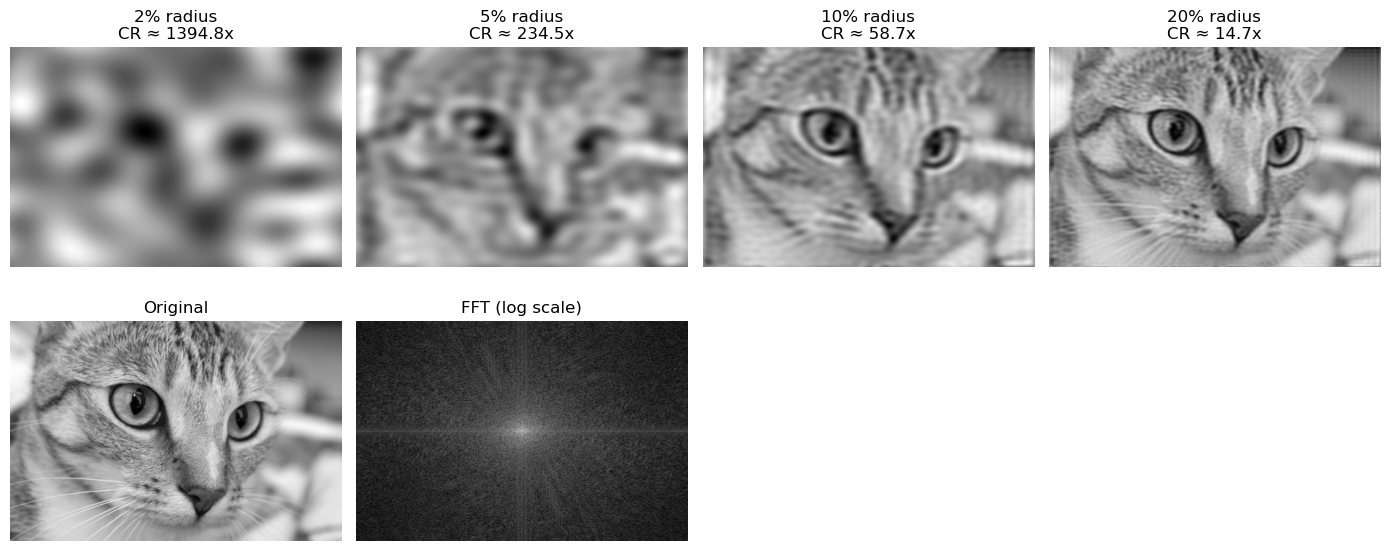

In [10]:
# ---- demo using the circular filter

# -------------------------------
# Load image (built-in cat)
# -------------------------------
img = data.chelsea()
img_gray = rgb2gray(img)

# -------------------------------
# FFT
# -------------------------------
F = np.fft.fft2(img_gray)
F_shift = np.fft.fftshift(F)

# -------------------------------
# Circular mask function
# -------------------------------
def circular_mask(F_shift, keep_fraction):
    M, N = F_shift.shape
    Y, X = np.ogrid[:M, :N]

    center = (M // 2, N // 2)

    # Radius proportional to keep_fraction
    max_radius = np.sqrt((M//2)**2 + (N//2)**2)
    radius = keep_fraction * max_radius

    dist = np.sqrt((Y - center[0])**2 + (X - center[1])**2)

    mask = dist <= radius

    return F_shift * mask, mask

# -------------------------------
# Try different compression levels
# -------------------------------
fractions = [0.02, 0.05, 0.1, 0.2]

plt.figure(figsize=(14,6))

for i, frac in enumerate(fractions):
    F_comp, mask = circular_mask(F_shift, frac)

    # Reconstruction
    img_rec = np.fft.ifft2(np.fft.ifftshift(F_comp))
    img_rec = np.abs(img_rec)

    # Compression ratio
    total = F_shift.size
    kept = np.sum(mask)
    ratio = total / kept

    # Plot reconstructed image
    plt.subplot(2, len(fractions), i+1)
    plt.imshow(img_rec, cmap='gray')
    plt.title(f"{int(frac*100)}% radius\nCR ≈ {ratio:.1f}x")
    plt.axis('off')

# -------------------------------
# Original image
# -------------------------------
plt.subplot(2, len(fractions), len(fractions)+1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

# -------------------------------
# FFT magnitude (log scale)
# -------------------------------
plt.subplot(2, len(fractions), len(fractions)+2)
plt.imshow(np.log(1 + np.abs(F_shift)), cmap='gray')
plt.title("FFT (log scale)")
plt.axis('off')

plt.tight_layout()
plt.show()